In [1]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
LOG.propagate = False

In [2]:
# Get ArtemisBLEController object
ble = get_ble_controller()
# Connect to the Artemis Device
ble.connect()

2025-03-25 18:15:45,352 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:e0:ec:f0:72:02
2025-03-25 18:15:49,836 | INFO     |: Connected to c0:e0:ec:f0:72:02


C:\CornellCourse\ECE5160\ble_robot_1.2\ble_python\base_ble.py:104: FutureWarning: This method will be removed future version, pass the callback to the BleakClient constructor instead.
  self.client.set_disconnected_callback(self.disconnect_handler)


In [ ]:
step_time = []
step_dist = []
step_motor = []

def step_data_notification_handler(uuid, byte_arr):
    msg = byte_arr.decode('utf-8').strip()
    # Expect something like: "T:1234|D:250|M:100"
    if msg.startswith("T:"):
        parts = msg.split("|")
        if len(parts) == 3:
            t_str = parts[0].split(":")[1]
            d_str = parts[1].split(":")[1]
            m_str = parts[2].split(":")[1]
            step_time.append(float(t_str))
            step_dist.append(float(d_str))
            step_motor.append(float(m_str))
        else:
            print("Incomplete step data:", msg)
    else:
        print("Ack or other message:", msg)

In [ ]:
ble.start_notify(ble.uuid['RX_STRING'], step_data_notification_handler)

In [95]:
step_pwm = 150 
step_duration_ms = 3000  # run 3 seconds, then stop
ble.send_command(CMD.START_STEP_RESPONSE, f"{step_pwm}|{step_duration_ms}")

Ack or other message: Step Start: PWM=-150 Duration=3000


In [96]:
# Clear any old arrays
step_time.clear()
step_dist.clear()
step_motor.clear()
ble.send_command(CMD.SEND_STEP_DATA, "")

In [98]:
print(len(step_time))
print(len(step_dist))
print(len(step_motor))

31
31
31


In [99]:
time_s = np.array(step_time)/1000  # convert ms -> s
dist_m = np.array(step_dist) # mm -> m (or keep in mm, just be consistent)
motor_cmd = np.array(step_motor)
# Compute speed: v[i] = (dist[i+1] - dist[i]) / (time[i+1] - time[i])
v = []
for i in range(len(time_s)-1):
    dt = time_s[i+1] - time_s[i]
    dd = dist_m[i+1] - dist_m[i]
    v.append(-dd / dt)
# For plotting alignment, you might shift v by half a step or just lose one point
time_v = 0.5*(time_s[1:] + time_s[:-1])

In [106]:
print(v)
print(time_s)
# # Example: keep only the velocities between 0 and 2000
# # and filter the corresponding times accordingly
# vv = [val for val in v if 0 < val < 2000]
# time_ss = [time_s[i] for i in range(len(v)) if 0 < v[i] < 2000]


[np.float64(-29.99999999999318), np.float64(49.504950495049954), np.float64(2692.3076923085714), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-0.0), np.float64(-20480.000000006985), np.float64(1529.9999999996521), np.float64(1680.000000000573), np.float64(1505.0505050498), np.float64(1721.6494845364375), np.float64(1422.764227642387), np.float64(1799.9999999995907), np.float64(1870.0000000006378), np.float64(1990.099009901008), np.float64(2029.9999999995384), np.float64(2110.00000000072), np.float64(2285.714285713978), np.float64(-509.8039215684661), np.float64(-1070.000000000365), np.float64(-539.9999999998772), np.float64(865.9793814434776), np.float64(1291.262135922222), np.float64(59.99999999998636), np.float64(-10.00000000000341)]
[296.729 296.829 296.93  297.008 297.11  297.209 297.31  297.409 297.512
 297.609 297.707 297.809 297.909 298.009 298.109 298.208 298.305 298.428
 298.528 298.628

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10), dpi=100)  # larger figure with higher dpi

# Subplot 1: ToF Distance vs Time
plt.subplot(3, 1, 1)
plt.plot(time_s, dist_m, '-', linewidth=2, marker='o', markersize=4)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Distance (m)", fontsize=14)
plt.title("ToF Distance vs Time", fontsize=16)
plt.grid(True)

# Subplot 2: Estimated Speed vs Time
plt.subplot(3, 1, 2)
plt.plot(time_s, v, 'g-', linewidth=2, marker='s', markersize=4)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Speed (m/s)", fontsize=14)
plt.title("Estimated Speed vs Time", fontsize=16)
plt.grid(True)

# Subplot 3: Motor Input vs Time
plt.subplot(3, 1, 3)
plt.plot(time_s, motor_cmd, '-', linewidth=2, marker='^', markersize=4)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Motor PWM", fontsize=14)
plt.title("Motor Input vs Time", fontsize=16)
plt.grid(True)

plt.tight_layout()
plt.show()


In [39]:
import csv

with open('step_response_data.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['time_s','dist_mm','motor_pwm'])
    for i in range(len(step_time)):
        writer.writerow([time_s[i], step_dist[i], motor_cmd[i]])


In [3]:
u = 130 / 255
v_final = 1700
d = u / v_final
v_nighty = 1530
t_nighty = 1.5
m = -d * t_nighty / (np.log(1 - 0.9))
print("d:", d, "m:", m)

d: 0.00029988465974625144 m: 0.00019535737940284682


In [95]:
import numpy as np
import matplotlib.pyplot as plt
Delta_t = 0.1     # 10 Hz
A = np.array([[0,    1],
              [0, -d/m ]])
B = np.array([[0],
              [1/m ]])
Ad = np.eye(2) + Delta_t*A
Bd = Delta_t*B
C = np.array([[1, 0]]) 
Sigma_u = np.diag([15.0**2/Delta_t, 15.0**2/Delta_t])  # process noise
Sigma_z = np.array([[10.0**2]])       # measurement noise
# Initial guess for state and covariance
x0 = np.array([[800.0],   # position (mm)
               [   0.0]])  # velocity (mm/s)
Sigma0 = np.eye(2)*1e3     # large initial uncertainty

In [96]:
def kf(mu, sigma, u, z):
    """
    mu, sigma: current state estimate and covariance (2x1 and 2x2)
    u        : scalar input
    z        : scalar measurement (ToF distance)
    returns: updated (mu, sigma)
    """
    # 1) Predict
    mu_p = Ad @ mu + Bd * u
    sigma_p = Ad @ sigma @ Ad.T + Sigma_u
    # 2) Measurement update
    S = C @ sigma_p @ C.T + Sigma_z         # innovation covariance
    K = sigma_p @ C.T @ np.linalg.inv(S)    # Kalman gain
    y_tilde = z - (C @ mu_p)                # measurement residual
    mu_new = mu_p + K @ y_tilde
    sigma_new = (np.eye(2) - K @ C) @ sigma_p
    return mu_new, sigma_new

In [97]:
df = pd.read_csv("step_response_data.csv")  # e.g. columns: time_s, dist_mm, motor_pwm
time_meas = df["time_s"].values
dist_meas = df["dist_mm"].values
pwm_meas  = df["motor_pwm"].values

In [98]:
t_start = time_meas[0]
t_end   = time_meas[-1]
t_uniform = np.arange(t_start, t_end, Delta_t)
# Interpolate distance and PWM onto that time grid
dist_uniform = np.interp(t_uniform, time_meas, dist_meas)
pwm_uniform  = np.interp(t_uniform, time_meas, pwm_meas)

In [99]:
# Initialize
mu = x0.copy()
sigma = Sigma0.copy()
kf_positions = []
kf_velocities = []
for i in range(len(t_uniform)):
    u = pwm_uniform[i]/255.0  
    z = dist_uniform[i]  # mm
    mu, sigma = kf(mu, sigma, u, z)
    kf_positions.append(mu[0,0])
    kf_velocities.append(mu[1,0])

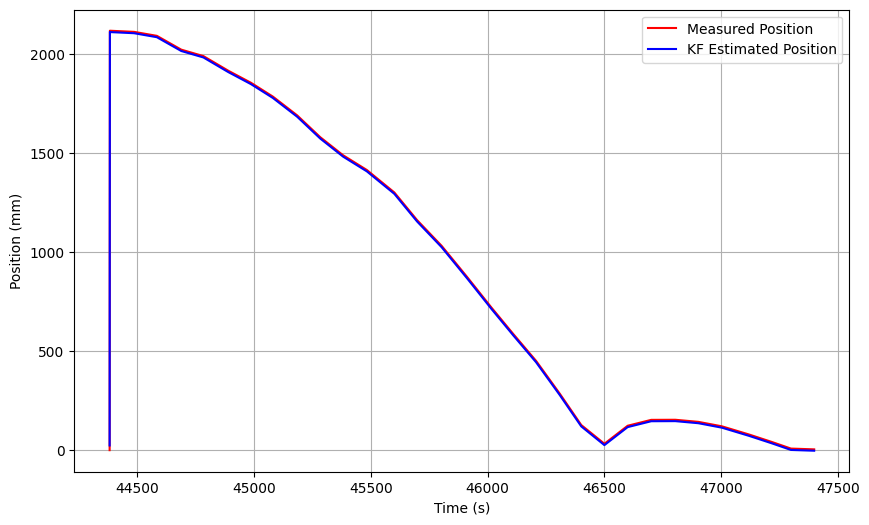

In [100]:
plt.figure(figsize=(10,6))

plt.plot(t_uniform, dist_uniform, 'r-', label="Measured Position")
plt.plot(t_uniform, kf_positions,  'b-', label="KF Estimated Position")
plt.xlabel("Time (s)")
plt.ylabel("Position (mm)")
plt.legend()
plt.grid()

plt.show()


In [328]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt
LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [329]:
# Get ArtemisBLEController object
ble = get_ble_controller()
# Connect to the Artemis Device
ble.connect()

2025-03-25 20:15:11,812 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:e0:ec:f0:72:02
2025-03-25 20:15:15,566 | INFO     |: Connected to c0:e0:ec:f0:72:02


In [330]:
# Global lists to store the PID+ToF+KF+Motor data
pid_time = []           # T: (ms)
pid_error = []          # E:
pid_output = []         # U:
pid_tof_dist = []       # R: raw ToF sensor distance
pid_kf_dist = []        # X: KF distance
pid_motor = []          # M:
notification_count = 0
def pid_notification_handler(sender: int, data: bytearray):
    global notification_count
    global pid_time, pid_error, pid_output, pid_tof_dist, pid_kf_dist, pid_motor
    try:
        message = data.decode("utf-8").strip()
        # Expected format: "T:xxx|E:xxx|U:xxx|R:xxx|X:xxx|M:xxx"
        if message.startswith("T:"):
            parts = message.split("|")
            if len(parts) < 6:
                print(f"Incomplete PID data: {message}")
                return   
            # parse each field
            t = float(parts[0].split(":")[1])  # T
            e = float(parts[1].split(":")[1])  # E
            u = float(parts[2].split(":")[1])  # U
            r = float(parts[3].split(":")[1])  # R
            x = float(parts[4].split(":")[1])  # X
            m = float(parts[5].split(":")[1])  # M
            # append to global lists
            pid_time.append(t)
            pid_error.append(e)
            pid_output.append(u)
            pid_tof_dist.append(r)
            pid_kf_dist.append(x)
            pid_motor.append(m)
            notification_count += 1
            print(f"PID Data #{notification_count}: {message}")
        else:
            print(f"Ack or other notification: {message}")

    except Exception as ex:
        print("Error parsing notification:", ex)


In [331]:
ble.start_notify(ble.uuid['RX_STRING'], pid_notification_handler)


In [365]:
# Step 1: Set PID Gains
ble.send_command(CMD.SET_PID_GAINS, "0.2|0.00025|0.15|300")

Ack or other notification: PID Gains Updated: Kp=0.200, Ki=0.000, Kd=0.150, Setpoint=300.000


In [366]:
ble.send_command(CMD.SET_KF_PARAMETERS, "30|0|0")

Ack or other notification: KF Params Updated: sigma_pos=0.000, sigma_vel=30.000, sigma_z=0.000


In [367]:
# Step 2: Start PID Control Test
# Instruct the device to run PID control for 5000 ms (5 seconds).
ble.send_command(CMD.START_PID_CONTROL, "3000")
# Wait a bit longer than the test duration to ensure the test completes.

Ack or other notification: Starting PID control for 3000 ms


In [358]:
pid_time = []           # T: (ms)
pid_error = []          # E:
pid_output = []         # U:
pid_tof_dist = []       # R: raw ToF sensor distance
pid_kf_dist = []        # X: KF distance
pid_motor = []          # M:

In [359]:
# Step 3: Request Logged PID+ToF Data
ble.send_command(CMD.GET_PID_DATA, "")

PID Data #1082: T:201463|E:-708.170|U:-162.581|R:1009.000|X:1008.170|M:-162
PID Data #1083: T:201464|E:-708.022|U:-160.050|R:1009.000|X:1008.022|M:-160
PID Data #1084: T:201475|E:-707.793|U:-161.831|R:1009.000|X:1007.793|M:-161
PID Data #1085: T:201480|E:-707.486|U:-162.012|R:1009.000|X:1007.486|M:-162
PID Data #1086: T:201489|E:-707.101|U:-162.687|R:1009.000|X:1007.101|M:-162
PID Data #1087: T:201500|E:-712.000|U:-178.914|R:1012.000|X:1012.000|M:-178
PID Data #1088: T:201506|E:-711.922|U:-177.350|R:1012.000|X:1011.922|M:-177
PID Data #1089: T:201512|E:-711.757|U:-175.634|R:1012.000|X:1011.757|M:-175
PID Data #1090: T:201517|E:-711.503|U:-173.547|R:1012.000|X:1011.503|M:-173
PID Data #1091: T:201523|E:-711.164|U:-171.673|R:1012.000|X:1011.164|M:-171
PID Data #1092: T:201529|E:-710.740|U:-169.724|R:1012.000|X:1010.740|M:-169
PID Data #1093: T:201540|E:-710.234|U:-168.869|R:1012.000|X:1010.234|M:-168
PID Data #1094: T:201549|E:-709.647|U:-167.572|R:1012.000|X:1009.647|M:-167
PID Data #10

In [360]:
print(f"Collected Data Lengths: Time={len(pid_time)}, Error={len(pid_error)}, ToF={len(pid_tof_dist)}, KF={len(pid_kf_dist)}")

Collected Data Lengths: Time=375, Error=375, ToF=375, KF=375


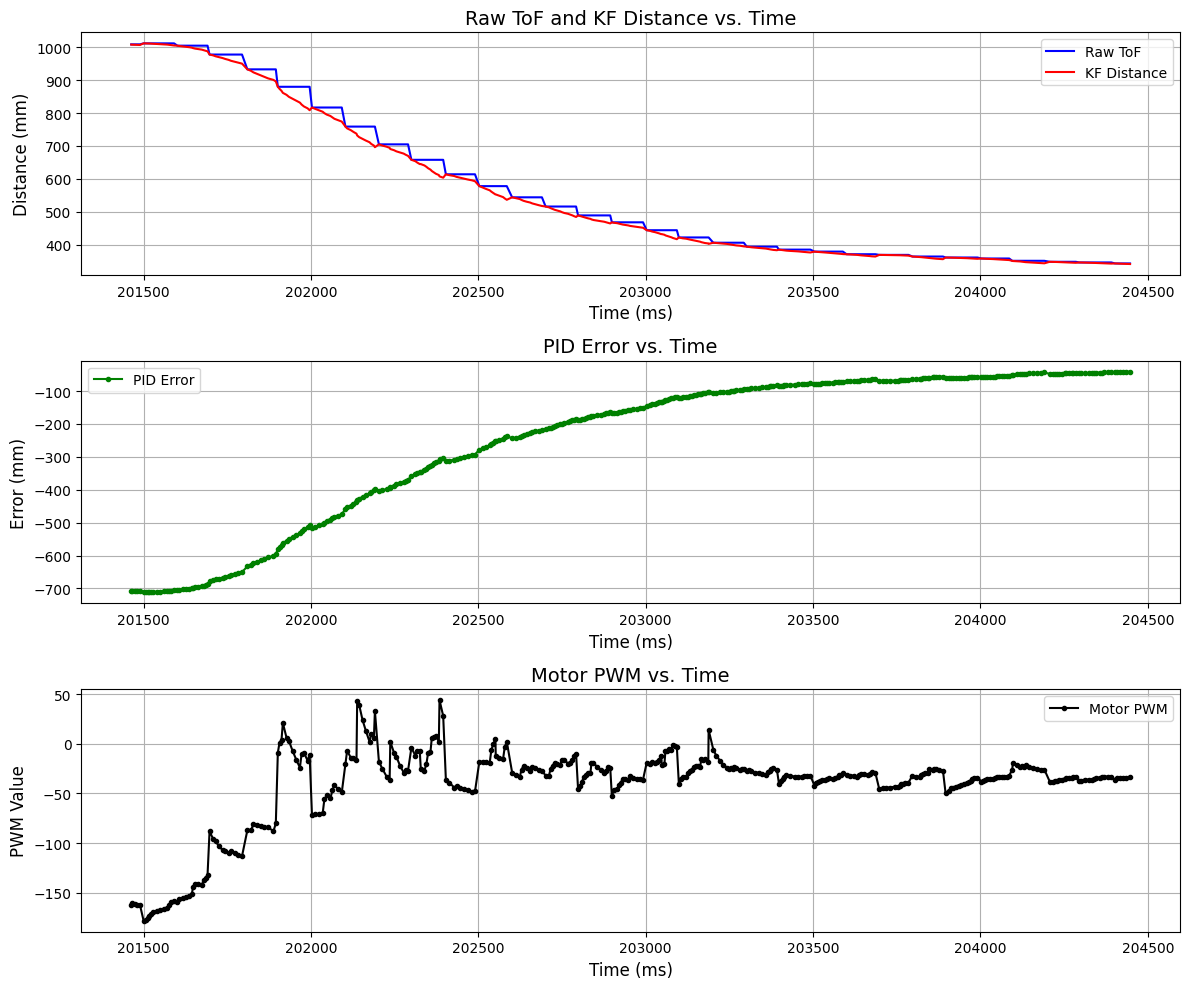

In [361]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
# -- Subplot 1: ToF + KF on the same axes --
plt.subplot(3,1,1)
plt.plot(pid_time, pid_tof_dist, 'b', label='Raw ToF')
plt.plot(pid_time, pid_kf_dist, 'r', label='KF Distance')
plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Distance (mm)", fontsize=12)
plt.title("Raw ToF and KF Distance vs. Time", fontsize=14)
plt.legend()
plt.grid(True)
# -- Subplot 2: PID Error vs. Time --
plt.subplot(3,1,2)
plt.plot(pid_time, pid_error, 'g.-', label='PID Error')
plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Error (mm)", fontsize=12)
plt.title("PID Error vs. Time", fontsize=14)
plt.legend()
plt.grid(True)
# -- Subplot 3: Motor PWM vs. Time --
plt.subplot(3,1,3)
plt.plot(pid_time, pid_motor, 'k.-', label='Motor PWM')
plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("PWM Value", fontsize=12)
plt.title("Motor PWM vs. Time", fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

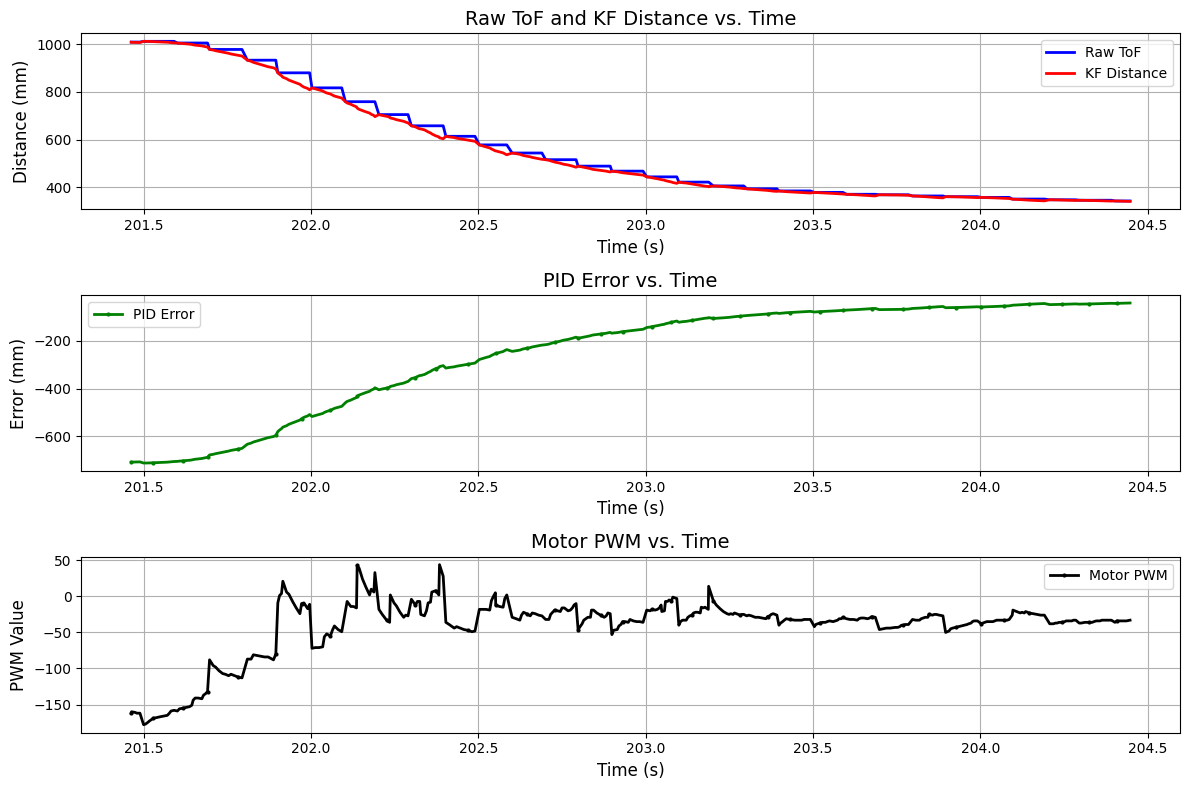

2025-03-25 20:23:11,726 | INFO     |: Disconnected from C0:E0:EC:F0:72:02


In [368]:
import matplotlib.pyplot as plt

# Example: Convert times from ms to seconds for nicer x-axis
pid_time_s = [t * 1e-3 for t in pid_time]

plt.figure(figsize=(12, 8))

# --- Subplot 1: ToF + KF ---
plt.subplot(3,1,1)
plt.plot(pid_time_s, pid_tof_dist, 'b-', linewidth=2, label='Raw ToF')
plt.plot(pid_time_s, pid_kf_dist,  'r-', linewidth=2, label='KF Distance')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Distance (mm)", fontsize=12)
plt.title("Raw ToF and KF Distance vs. Time", fontsize=14)
plt.legend()
plt.grid(True)

# --- Subplot 2: PID Error ---
plt.subplot(3,1,2)
# If you want markers but fewer, use marker='o' and markevery=10 or so:
plt.plot(pid_time_s, pid_error, color='g', linewidth=2, marker='.', 
         markersize=4, markevery=10, label='PID Error')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Error (mm)", fontsize=12)
plt.title("PID Error vs. Time", fontsize=14)
plt.legend()
plt.grid(True)

# --- Subplot 3: Motor PWM ---
plt.subplot(3,1,3)
plt.plot(pid_time_s, pid_motor, 'k-', linewidth=2, marker='.', 
         markersize=4, markevery=10, label='Motor PWM')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("PWM Value", fontsize=12)
plt.title("Motor PWM vs. Time", fontsize=14)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
